In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder



In [ ]:
db = pd.read_csv("creditcard.csv")


In [ ]:
db.shape


(9965, 31)

In [ ]:
db.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9965 entries, 0 to 9964
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    9965 non-null   int64  
 1   V1      9965 non-null   float64
 2   V2      9965 non-null   float64
 3   V3      9964 non-null   float64
 4   V4      9964 non-null   float64
 5   V5      9964 non-null   float64
 6   V6      9964 non-null   float64
 7   V7      9964 non-null   float64
 8   V8      9964 non-null   float64
 9   V9      9964 non-null   float64
 10  V10     9964 non-null   float64
 11  V11     9964 non-null   float64
 12  V12     9964 non-null   float64
 13  V13     9964 non-null   float64
 14  V14     9964 non-null   float64
 15  V15     9964 non-null   float64
 16  V16     9964 non-null   float64
 17  V17     9964 non-null   float64
 18  V18     9964 non-null   float64
 19  V19     9964 non-null   float64
 20  V20     9964 non-null   float64
 21  V21     9964 non-null   float64
 22  

In [ ]:
db.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,9965.000000,9965.000000,9965.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,...,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000
mean,5934.484897,-0.241681,0.280693,0.906359,0.260247,-0.046342,0.132335,-0.071847,-0.065317,0.801220,...,-0.052099,-0.152091,-0.033426,0.021638,0.087302,0.108328,0.005614,0.003051,62.968359,0.003814
std,4449.407112,1.522695,1.308882,1.156948,1.440500,1.183634,1.307586,1.077872,1.260140,1.156424,...,0.914735,0.631310,0.488203,0.593818,0.428128,0.562661,0.411434,0.266532,184.626707,0.061641
min,0.000000,-27.670569,-34.607649,-15.496222,-4.657545,-32.092129,-23.496714,-26.548144,-23.632502,-6.329801,...,-11.468435,-8.527145,-15.144340,-2.512377,-2.577363,-1.338556,-7.976100,-3.509250,0.000000,0.000000
25%,2061.000000,-1.012157,-0.208591,0.412198,-0.615591,-0.643060,-0.630075,-0.542336,-0.190495,0.069439,...,-0.268191,-0.548412,-0.174222,-0.327438,-0.157704,-0.328193,-0.084489,-0.015751,5.000000,0.000000
50%,4547.000000,-0.372624,0.286179,0.943149,0.218492,-0.153090,-0.153577,-0.054658,0.012466,0.804930,...,-0.123101,-0.136078,-0.046009,0.079935,0.121180,0.043395,-0.004505,0.015904,15.950000,0.000000
75%,10163.000000,1.151506,0.900823,1.601871,1.119367,0.371762,0.503376,0.476280,0.273016,1.506066,...,0.032707,0.247913,0.081288,0.410877,0.359418,0.478249,0.121045,0.077418,50.792500,0.000000
max,14864.000000,1.960497,8.636214,4.101716,10.463020,34.099309,21.393069,34.303177,5.060381,10.392889,...,22.588989,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000,1.000000


In [ ]:
db.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,1
V4,1
V5,1
V6,1
V7,1
V8,1
V9,1


In [ ]:
db.dropna(inplace=True)

In [ ]:
db.duplicated().sum()

np.int64(42)

In [ ]:
db.drop_duplicates(inplace=True)

In [ ]:
db.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
db['Class'].value_counts()

,count
Class,
0.0,9884
1.0,38


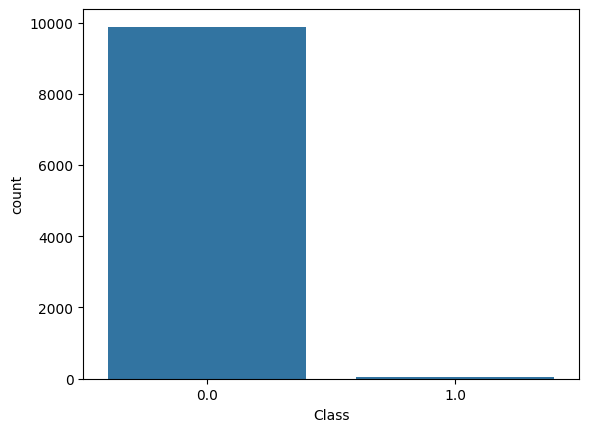

In [ ]:
sns.countplot(data=db,x="Class")
plt.show()

<Figure size 800x1000 with 0 Axes>

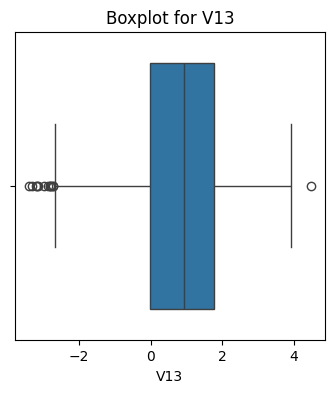

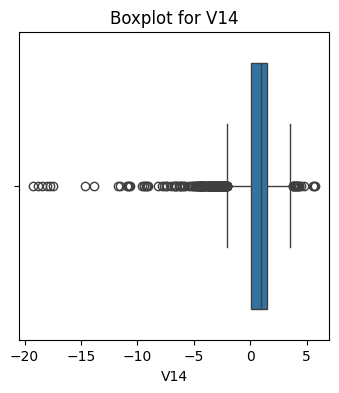

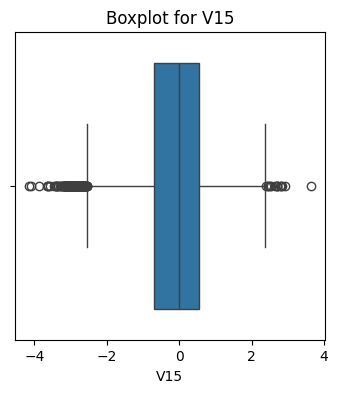

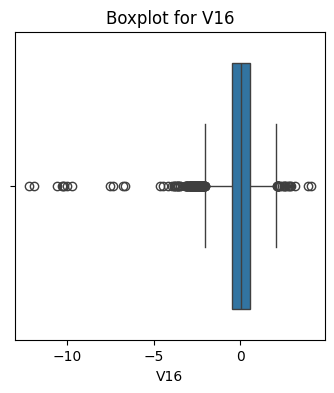

In [ ]:
plt.figure(figsize=(8,10))
columns=["V13","V14","V15","V16"]
for column in columns:
    plt.figure(figsize=(4,4))
    sns.boxplot(x=db[column])
    plt.title(f'Boxplot for {column}')
    plt.show()


In [ ]:
print(len(db))

9922


In [ ]:
def delete_outlayer(db,colum_name):
    Q1=db[colum_name].quantile(0.25)
    Q3=db[colum_name].quantile(0.75)
    iqr=Q3-Q1
    lowwerbound=Q1-1.5 *iqr
    upperbound=Q3+1.5 * iqr
    df_without_outliers=db[((db[colum_name])>=lowwerbound )& ((db[colum_name]<=upperbound))]
    return df_without_outliers

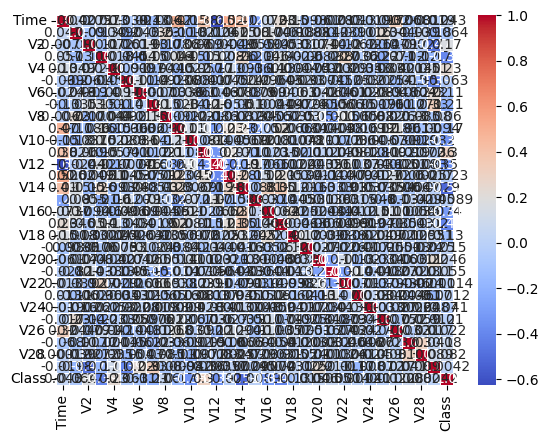

In [ ]:
correlation_matrix=db.corr()
sns.heatmap(correlation_matrix,annot=True , fmt=".2",cmap="coolwarm",linewidths=0.5)
plt.show()

In [ ]:
correlation_with_class=db.corr()["Class"].sort_values(ascending=False)
print(correlation_with_class)

Class     1.000000
V11       0.298494
V4        0.230431
V2        0.167853
V28       0.082013
V27       0.080048
V8        0.060194
V21       0.054802
V20       0.046082
Time      0.043454
V26       0.022154
V19       0.015270
Amount    0.004216
V23       0.001202
V22      -0.001398
V15      -0.008896
V25      -0.010047
V13      -0.023085
V24      -0.041199
V5       -0.062883
V1       -0.063737
V6       -0.106213
V18      -0.130759
V9       -0.165008
V7       -0.213270
V16      -0.312922
V10      -0.345954
V12      -0.352290
V3       -0.392257
V17      -0.408942
V14      -0.519017
Name: Class, dtype: float64


In [ ]:
x = db.drop('Class',axis=1)
y = db['Class']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
scaler=RobustScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=.015)
lasso.fit(x_train, y_train)

Lasso(alpha=0.015)

In [ ]:
from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error
y_pred=lasso.predict(x_test)
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.01197361277573329
0.0021225382571018352


In [ ]:
model=GaussianNB()
model.fit(x_train,y_train)

GaussianNB()

In [ ]:
y_predict_train=model.predict(x_train)
y_predict=model.predict(x_test)

In [ ]:
accuracy_of_train=accuracy_score(y_predict_train,y_train)
accuracy_of_test=accuracy_score(y_predict,y_test)
print(f"accuracy_of_train is{accuracy_of_train}")
print(f"accuracy_of_test is{accuracy_of_test}")

accuracy_of_train is0.9874730021598273
accuracy_of_test is0.987571380584481


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predict)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[2930   37]
 [   0   10]]


In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      2967
         1.0       0.21      1.00      0.35        10

    accuracy                           0.99      2977
   macro avg       0.61      0.99      0.67      2977
weighted avg       1.00      0.99      0.99      2977



In [ ]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x_train,y_train)

In [ ]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

In [ ]:
model2=GaussianNB()
model2.fit(x_train2,y_train2)

GaussianNB()

In [ ]:
y_predict_train2=model2.predict(x_train2)
y_predict2=model2.predict(x_test2)

In [ ]:
accuracy_of_train2=accuracy_score(y_predict_train2,y_train2)
accuracy_of_test2=accuracy_score(y_predict2,y_test2)

In [ ]:
print(f"accuracy_of_train2 is{accuracy_of_train2}")
print(f"accuracy_of_test2 is{accuracy_of_test2}")

accuracy_of_train2 is0.9841991118455025
accuracy_of_test2 is0.9828956877860756


In [ ]:
print(classification_report(y_test2, y_predict2))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      2062
         1.0       0.99      0.97      0.98      2089

    accuracy                           0.98      4151
   macro avg       0.98      0.98      0.98      4151
weighted avg       0.98      0.98      0.98      4151



In [ ]:
cm2=confusion_matrix(y_test2, y_predict2)
print(cm2)

[[2046   16]
 [  55 2034]]


In [ ]:
#[[64726  1483]
# [   18    97]]
#result of the frist confision
#the  1 case 391

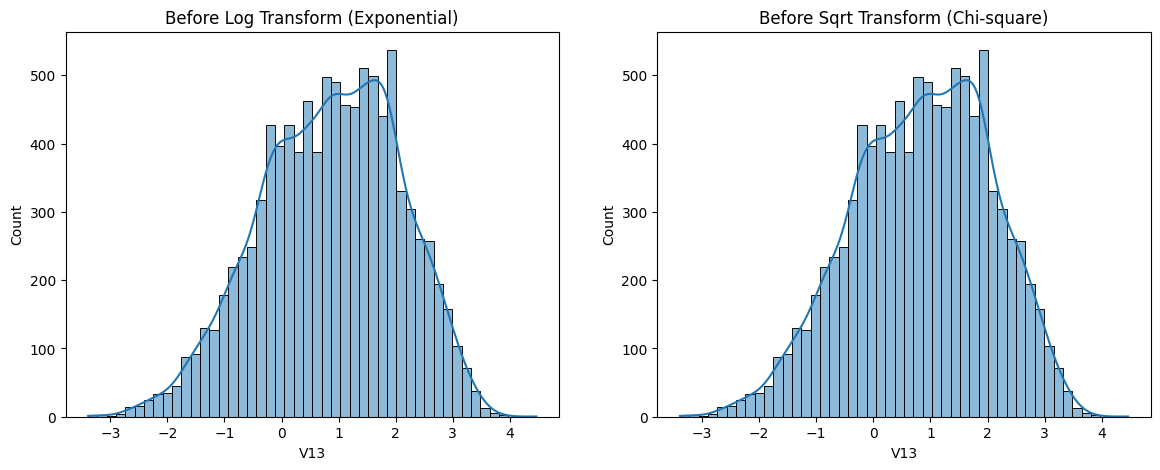

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(db['V13'], kde=True, ax=axes[0])
axes[0].set_title("Before Log Transform (Exponential)")

sns.histplot(db['V13'], kde=True, ax=axes[1])
axes[1].set_title("Before Sqrt Transform (Chi-square)")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train3, X_test3, y_train3, y_test3 = train_test_split(x, y, stratify=y, random_state=42)

clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train3, y_train3)

y_pred3 = clf.predict(X_test3)
print(classification_report(y_test3, y_pred3))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2471
         1.0       1.00      0.70      0.82        10

    accuracy                           1.00      2481
   macro avg       1.00      0.85      0.91      2481
weighted avg       1.00      1.00      1.00      2481



In [ ]:
import numpy as np
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal

class GaussianAnomalyDetector:
    def __init__(self, epsilon=1e-5):
        self.epsilon = epsilon

    def fit(self, X):
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)
        self.mu = np.mean(X_scaled, axis=0)
        self.cov = np.cov(X_scaled, rowvar=False)
        self.rv = multivariate_normal(mean=self.mu, cov=self.cov)
        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        probs = self.rv.pdf(X_scaled)
        return (probs < self.epsilon).astype(int)

    def score_samples(self, X):
        X_scaled = self.scaler.transform(X)
        return self.rv.pdf(X_scaled)

In [ ]:
X_data = db.drop(columns=['Class'])
y_data = db['Class'].values
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(X_data, y_data))
X_train, y_train = X_data.iloc[train_idx], y_data[train_idx]
X_val, y_val = X_data.iloc[val_idx], y_data[val_idx]

X_train_normal = X_train[y_train == 0]
model = GaussianAnomalyDetector().fit(X_train_normal)
probs_val = model.score_samples(X_val)

epsilons = np.percentile(probs_val, [0.1, 0.5, 1, 2, 5, 10])
best_f1 = -1
best_eps = None

for eps in epsilons:
    model.epsilon = eps
    preds = model.predict(X_val)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_eps = eps

model.epsilon = best_eps
y_pred = model.predict(X_data)
from sklearn.metrics import classification_report
print("Best epsilon:", best_eps)
print(classification_report(y_data, y_pred))


Best epsilon: 1.569666404859118e-186
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9884
         1.0       0.64      0.95      0.77        38

    accuracy                           1.00      9922
   macro avg       0.82      0.97      0.88      9922
weighted avg       1.00      1.00      1.00      9922



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import BatchNormalization , Dropout

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
db.shape

(9922, 31)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30,)),
    tf.keras.layers.Dense(70, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
output= model.fit(x_train,y_train,epochs=100, validation_data=(x_test,y_test))

Epoch 1/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9914 - loss: 2.4375 - val_accuracy: 0.9966 - val_loss: 0.5320
Epoch 2/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9913 - loss: 0.5929 - val_accuracy: 0.9966 - val_loss: 1.9237
Epoch 3/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9873 - loss: 2.3336 - val_accuracy: 0.9966 - val_loss: 2.9642
Epoch 4/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9960 - loss: 2.3256 - val_accuracy: 0.9963 - val_loss: 0.0800
Epoch 5/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9958 - loss: 0.2049 - val_accuracy: 0.9983 - val_loss: 0.1439
Epoch 6/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9939 - loss: 0.4580 - val_accuracy: 0.9943 - val_loss: 0.0980
Epoch 7/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9920 - loss: 0.4089 - val_accuracy: 0.9966 - val_loss: 1.5876
Epoch 8/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.6574 - val_accu